In [2]:
import requests, subprocess, glob, os, gc
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import pandas as pd

## Funciones

In [5]:
def descargar_datos_capitulo_iv(carpeta="datos_crudos"):
    if not os.path.exists(carpeta):
        os.makedirs(carpeta)

    url_pagina = "https://datos.gob.ar/dataset/energia-produccion-petroleo-gas-por-pozo-capitulo-iv"
    respuesta = requests.get(url_pagina)
    sopa = BeautifulSoup(respuesta.text, "html.parser")

    links_descarga = []

    for contenedor in sopa.find_all("div", class_="pkg-container"):
        h3 = contenedor.find("h3")
        p = contenedor.find("p")
        
        if h3 and p:
            titulo = h3.text.lower()
            descripcion = p.text.lower().strip()
            

            titulo_ok = "pozos de gas y petr" in titulo and "ddjj" not in titulo
            sin_identificador = "identificador" not in titulo and "identificador" not in descripcion
            es_convencional = "no convencional" not in titulo and "no convencional" not in descripcion
            desc_ok = descripcion == "" or "detalle mensual" in descripcion
            
            if titulo_ok and sin_identificador and es_convencional and desc_ok:
                for etiqueta in contenedor.find_all("a"):
                    link = etiqueta.get("href")
                    if link and ".csv" in link:
                        if link.startswith("/"):
                            link = "https://datos.gob.ar" + link
                        links_descarga.append(link)


    for url_csv in list(set(links_descarga)):
        nombre_archivo = url_csv.split("/")[-1]
        ruta_guardado = f"./{carpeta}/{nombre_archivo}"
        respuesta_csv = requests.get(url_csv, stream=True)
        with open(ruta_guardado, 'wb') as archivo:
            for bloque in respuesta_csv.iter_content(chunk_size=8192):
                archivo.write(bloque)
        
    print(f"✅ Descarga finalizada en la carpeta: {carpeta}")

def unir_y_guardar_datasets(carpeta="datos_crudos", nombre_salida="dataset_unificado_cap4.csv"):
    columnas_tp = [
        "anio", "mes", "empresa", "provincia", "areayacimiento", 
        "prod_pet", "prod_gas", "tipopozo", "tipo_de_recurso"
    ]
    
    archivos = glob.glob(f"./{carpeta}/*.csv")
    ruta_salida = f"./{carpeta}/{nombre_salida}"
    
    # Evitamos que lea el archivo unificado si ya existe en la carpeta
    ruta_salida_limpia = ruta_salida.replace("\\", "/")
    archivos_limpios = [a.replace("\\", "/") for a in archivos]
    if ruta_salida_limpia in archivos_limpios:
        archivos_limpios.remove(ruta_salida_limpia)
        
    df_final = pd.concat(
        (pd.read_csv(archivo, usecols=lambda c: c in columnas_tp, low_memory=False) for archivo in archivos_limpios), 
        ignore_index=True
    )
    
    df_final.to_csv(ruta_salida, index=False)
    print(f"✅ Dataset unificado guardado con éxito en: {ruta_salida}")
    
    return df_final

def fechas (df): #crea la columna de fecha_produccion
    texto_fecha = df['anio'].astype(str) + '-' + df['mes'].astype(str)
    df['fecha_produccion'] = pd.to_datetime(texto_fecha)
    return df


## Descarga, concatenado, y montaje del dataset

#### En caso de que se ejecute el archivo .ipynb por primera vez, y se ejecuten todas las celdas, el flujo de trabajo sera el siguiente:
Se ejecuta la funcion "descargar_datos_capitulo_iv", la cual descarga los datasets desde 2007 a 2026, luego se ejecuta la funcion que los concatena y filtra las columnas de interes para luego montarlo en memoria.
#### Caso contrario
se monta directamente el dataset unificado si ya existe 
#### Aclaracion
Para que el programa se ejecute de manera ordenada y optima, este trabajo se envio con una carpeta vacia llamada "datos_crudos", esa carpeta en principio vacia, es donde se descargaran todos los datasets, y en donde se creara el dataset unificado, y el resto del programa trabajara con ese directorio. En caso de modificarlo por conveniencia, se tiene que cambiar el parametro "carpeta" de las funciones de descarga y concatenado, lo mismo para las celdas posteriores

In [6]:
ruta_archivo_final = "./datos_crudos/dataset_unificado_cap4.csv"

# Verificamos si el archivo ya fue creado anteriormente
if os.path.exists(ruta_archivo_final):
    print("✅ El dataset unificado ya existe en el dispositivo. montándolo...")
    dataset = pd.read_csv(ruta_archivo_final)
else:
    print("⏳ El dataset no existe. Iniciando descarga y concatenado (esto puede demorar unos minutos)...")
    descargar_datos_capitulo_iv()
    dataset = unir_y_guardar_datasets()

print("--------------------------------------------------")
print("Dataset listo para usar")
print("Filas y columnas finales:", dataset.shape)

⏳ El dataset no existe. Iniciando descarga y concatenado (esto puede demorar unos minutos)...
✅ Descarga finalizada en la carpeta: datos_crudos
✅ Dataset unificado guardado con éxito en: ./datos_crudos/dataset_unificado_cap4.csv
--------------------------------------------------
Dataset listo para usar
Filas y columnas finales: (17791045, 9)


## Dataframe de gas y petróleo

Creo el dataframe de gas convencional y de produccion mayor a cero.

In [7]:
dataframe_gas = dataset[(dataset["tipopozo"] == "Gasífero") & (dataset["tipo_de_recurso"] == "CONVENCIONAL") & (dataset["prod_gas"] >= 0)].copy()

print("Tamaño del nuevo dataset:", dataframe_gas.shape)

Tamaño del nuevo dataset: (932146, 9)


Le agrego una columna mas, que va a ser "fecha_produccion", lo que va a hacer sera asignarle a cada fila segun el mes y año del dato, la fecha correspondiente, y trabajar a partir de esta columna

In [8]:
fechas(dataframe_gas)

,anio,mes,prod_pet,prod_gas,tipopozo,empresa,areayacimiento,provincia,tipo_de_recurso,fecha_produccion
325,2006,1,0.0,0.000000,Gasífero,YPF S.A.,RESTINGA ALI,Chubut,CONVENCIONAL,2006-01-01
343,2006,1,0.0,0.000000,Gasífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
364,2006,1,0.0,0.000000,Gasífero,YPF S.A.,RESTINGA ALI,Chubut,CONVENCIONAL,2006-01-01
372,2006,1,0.0,0.000000,Gasífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
388,2006,1,0.0,0.000000,Gasífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
...,...,...,...,...,...,...,...,...,...,...
17791005,2026,2,0.0,6.014393,Gasífero,EDHIPSA,ESTANCIA VIEJA,Rio Negro,CONVENCIONAL,2026-02-01
17791012,2026,2,0.0,0.000000,Gasífero,EDHIPSA,ESTANCIA VIEJA,Rio Negro,CONVENCIONAL,2026-02-01
17791022,2026,2,0.0,0.000000,Gasífero,EDHIPSA,ESTANCIA VIEJA,Rio Negro,CONVENCIONAL,2026-02-01
17791028,2026,2,0.0,0.000000,Gasífero,EDHIPSA,ESTANCIA VIEJA,Rio Negro,CONVENCIONAL,2026-02-01


Al igual que el dataframe del gas

In [9]:
dataframe_petroleo_s_Neuquen = dataset[
    (dataset["tipopozo"] == "Petrolífero") & 
    (dataset["tipo_de_recurso"] == "CONVENCIONAL") & 
    (dataset["prod_pet"] >= 0) & 
    ((dataset["provincia"] == "Santa Cruz") | (dataset["provincia"] == "Chubut"))].copy()

dataframe_petroleo_c_Neuquen = dataset[
    (dataset["tipopozo"] == "Petrolífero") & 
    (dataset["tipo_de_recurso"] == "CONVENCIONAL") & 
    (dataset["prod_pet"] >= 0) & 
    (dataset["provincia"] == "Neuquén")].copy()

In [10]:
fechas(dataframe_petroleo_c_Neuquen)
fechas(dataframe_petroleo_s_Neuquen)

,anio,mes,prod_pet,prod_gas,tipopozo,empresa,areayacimiento,provincia,tipo_de_recurso,fecha_produccion
319,2006,1,855.11,19.44,Petrolífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
320,2006,1,0.00,0.00,Petrolífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
321,2006,1,120.04,0.00,Petrolífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
322,2006,1,369.55,14.41,Petrolífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
323,2006,1,294.36,6.23,Petrolífero,YPF S.A.,MANANTIALES BEHR,Chubut,CONVENCIONAL,2006-01-01
...,...,...,...,...,...,...,...,...,...,...
17785988,2026,2,0.00,0.00,Petrolífero,CROWN POINT ENERGIA S.A.,EL TORDILLO,Chubut,CONVENCIONAL,2026-02-01
17785990,2026,2,0.00,0.00,Petrolífero,CROWN POINT ENERGIA S.A.,EL TORDILLO,Chubut,CONVENCIONAL,2026-02-01
17785991,2026,2,0.00,0.00,Petrolífero,CROWN POINT ENERGIA S.A.,EL TORDILLO,Chubut,CONVENCIONAL,2026-02-01
17785992,2026,2,0.00,0.00,Petrolífero,CROWN POINT ENERGIA S.A.,EL TORDILLO,Chubut,CONVENCIONAL,2026-02-01


## Graficos de produccion respecto al tiempo

Se grafica la produccion por mes de los pozos de gas de los 10 yacimientos con mayor produccion acumulada

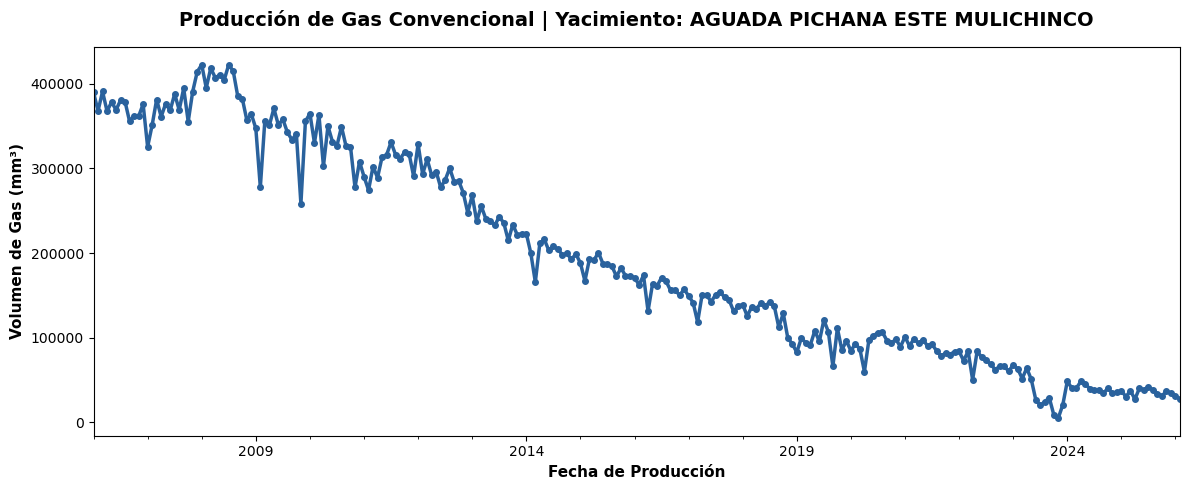

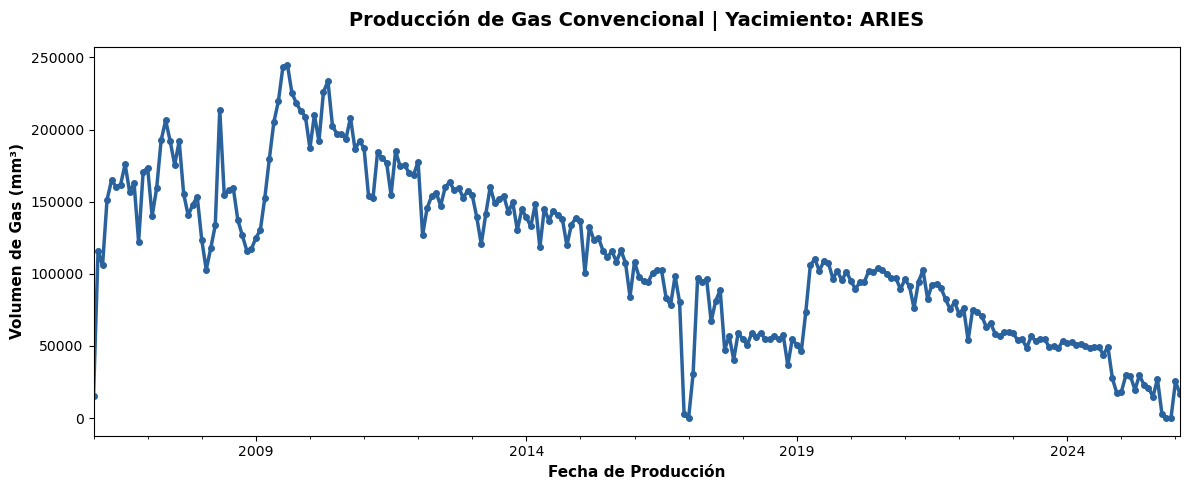

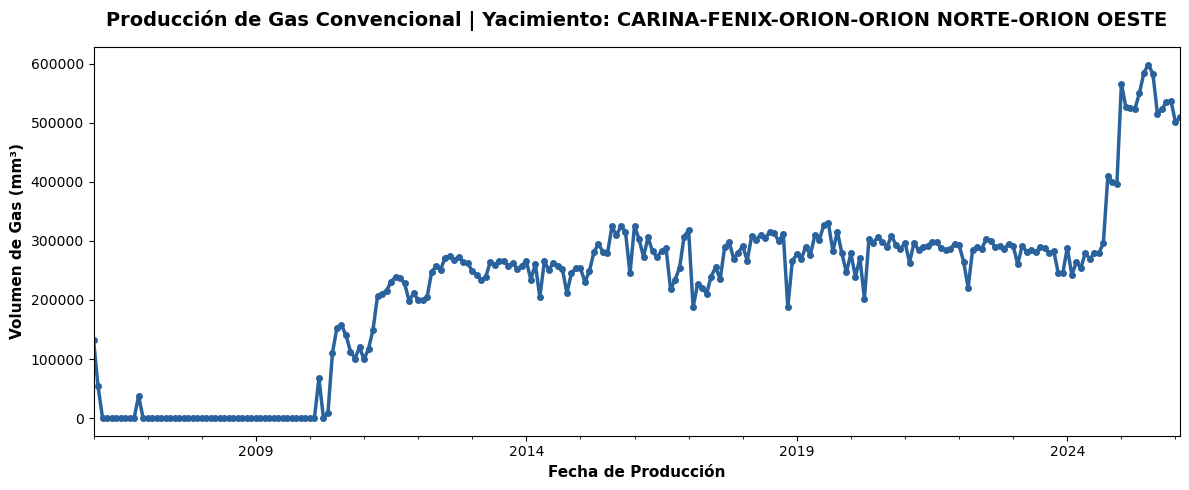

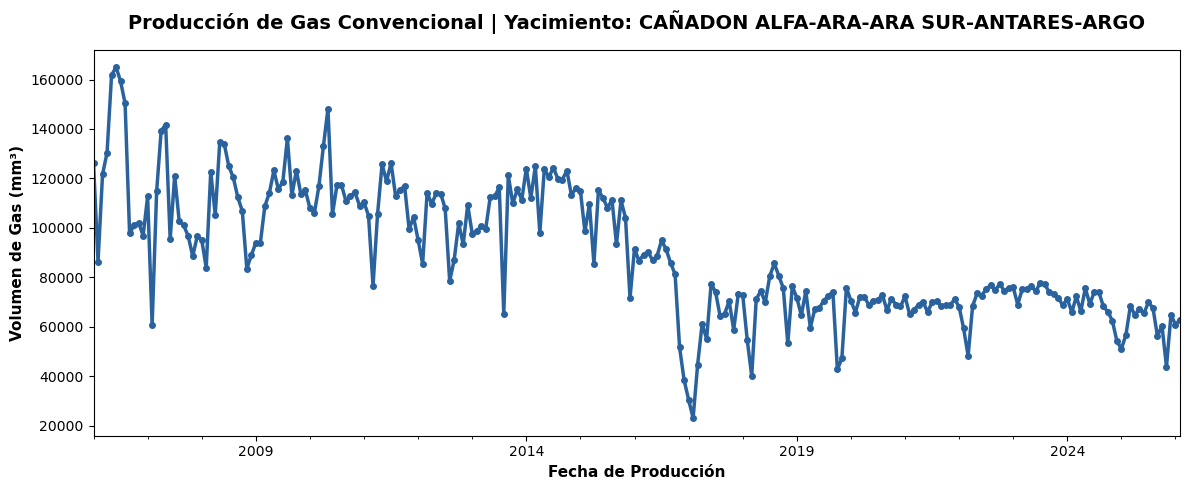

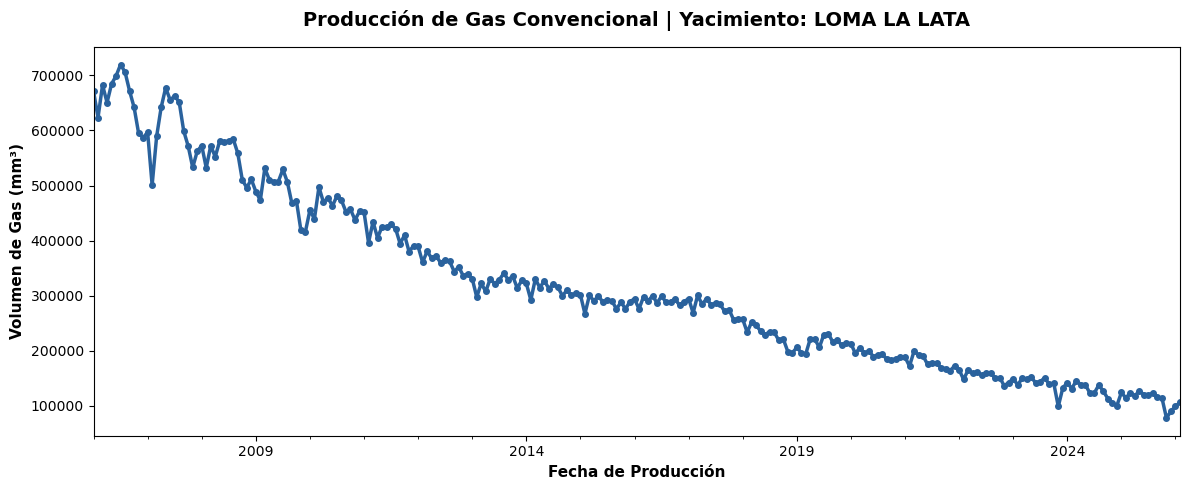

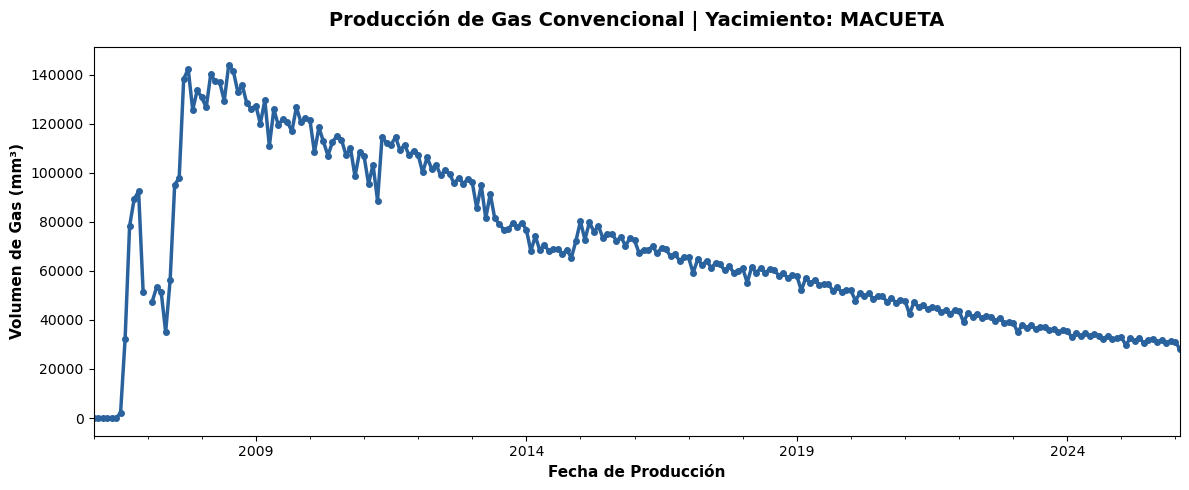

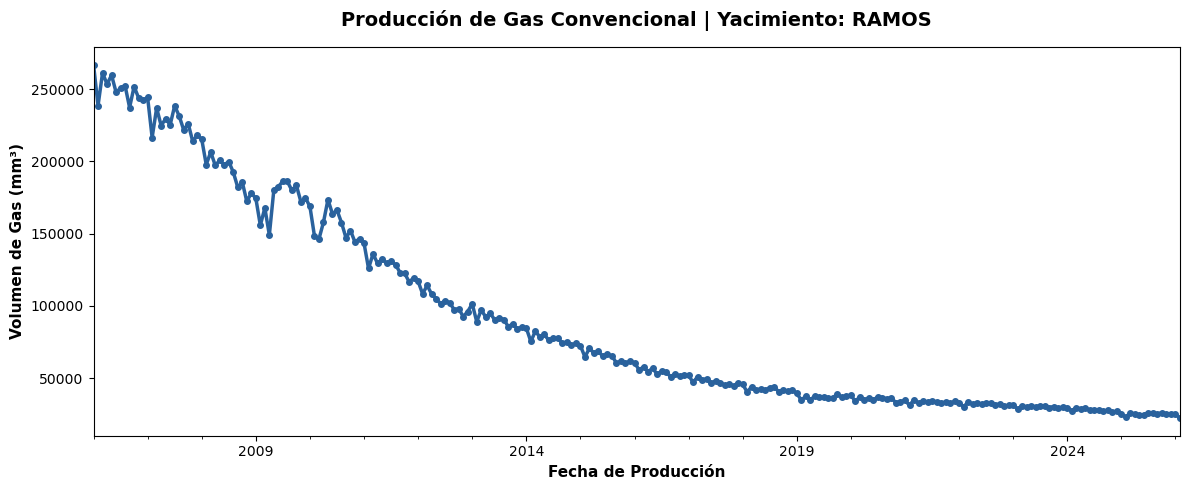

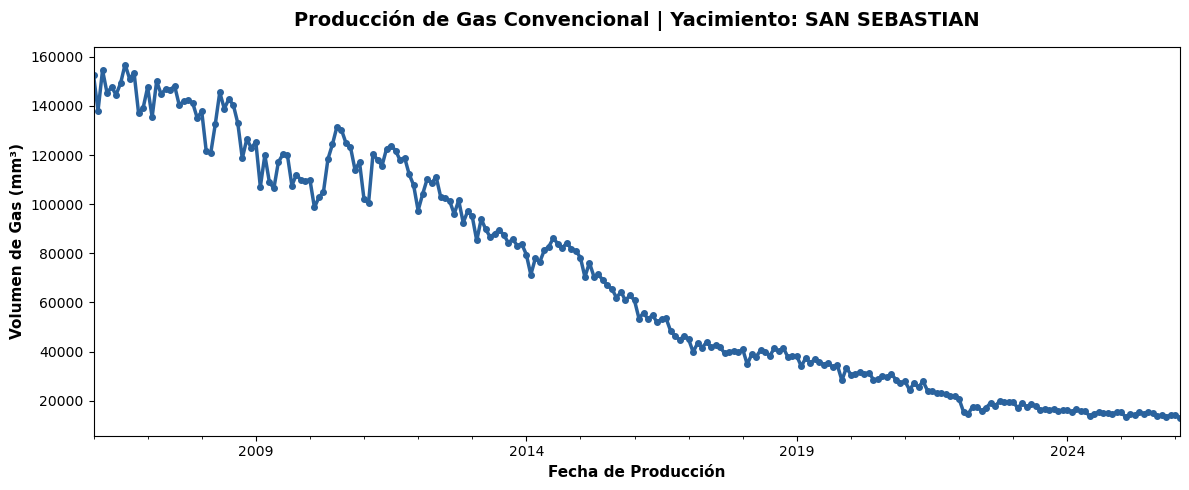

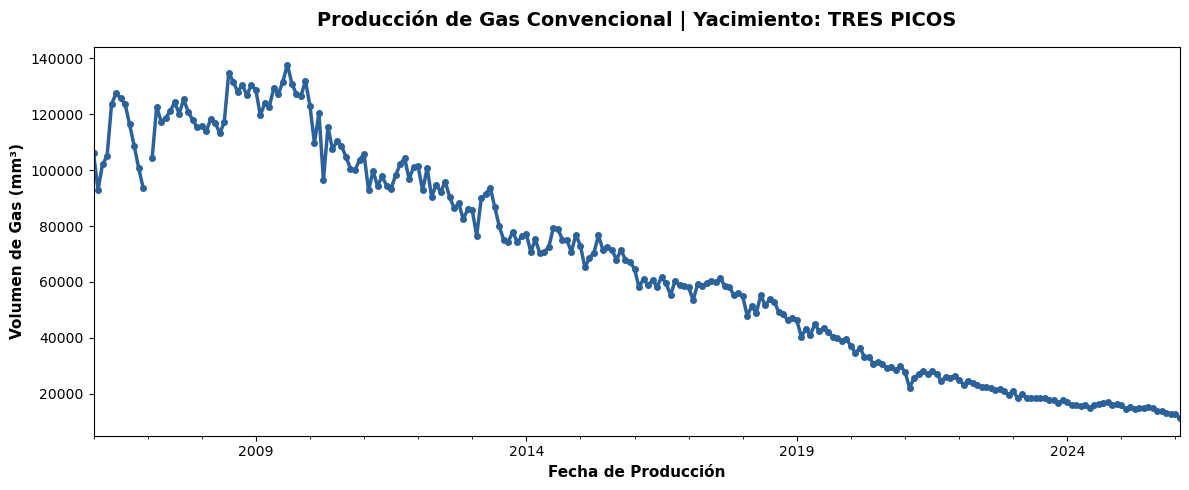

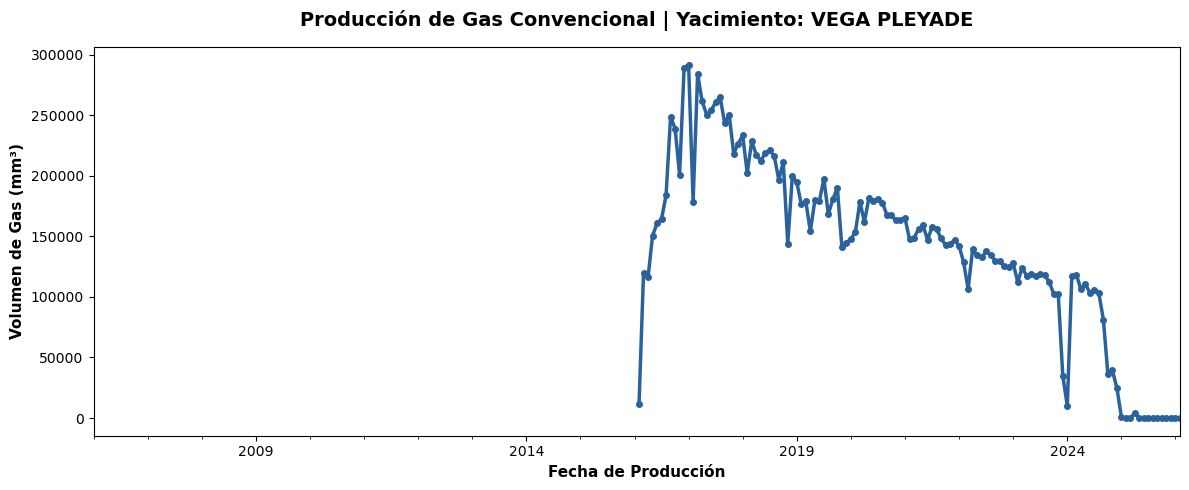

In [13]:
ranking_produccion = dataframe_gas.groupby("areayacimiento")["prod_gas"].sum()

top_10_nombres = ranking_produccion.nlargest(10).index #ordena los 10 yacimientos que mas produccion tienen y agarra los indices

df_top10 = dataframe_gas[dataframe_gas["areayacimiento"].isin(top_10_nombres)] #.isin agarra las filas que tengan el contenido del parentesis

datos_grafico = df_top10.pivot_table(index="fecha_produccion", columns="areayacimiento", values="prod_gas", aggfunc="sum")

for yacimiento in datos_grafico.columns:
    # 2. TUNEAR LA LÍNEA: Guardamos el gráfico en una variable 'ax' para modificarlo
    ax = datos_grafico[yacimiento].plot(
        figsize=(12, 5), 
        color="#2a629d",       # Podés usar códigos Hexadecimales para colores modernos
        linewidth=2.5,         # Hacemos la línea un poco más gruesa (por defecto es muy finita)
        marker='o',            # Le ponemos un puntito marcando cada dato real
        markersize=4           # Tamaño de ese puntito
    )
    
    # 3. TUNEAR LOS TEXTOS: Títulos y etiquetas de los ejes
    # pad=15 separa un poquito el título del gráfico para que respire
    plt.title(f"Producción de Gas Convencional | Yacimiento: {yacimiento}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Fecha de Producción", fontsize=11, fontweight='bold')
    plt.ylabel("Volumen de Gas (mm³)", fontsize=11, fontweight='bold')
    
    # 4. EMPROLIJAR: Esto evita que los textos se corten en los bordes de la imagen
    plt.tight_layout()
    
    # Mostramos el gráfico terminado
    plt.show()

Analogo al petroleo de Santa Cruz y Chubut

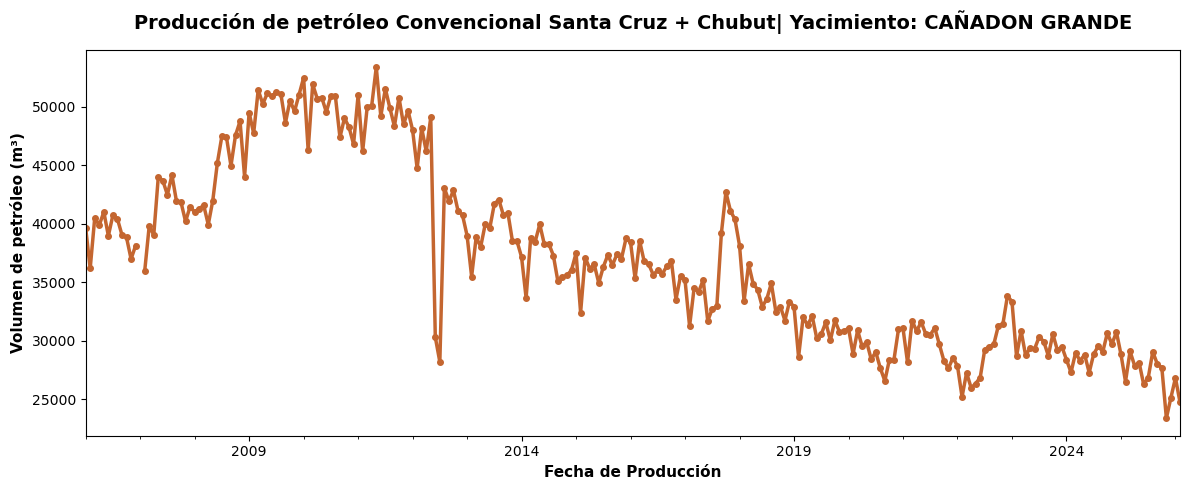

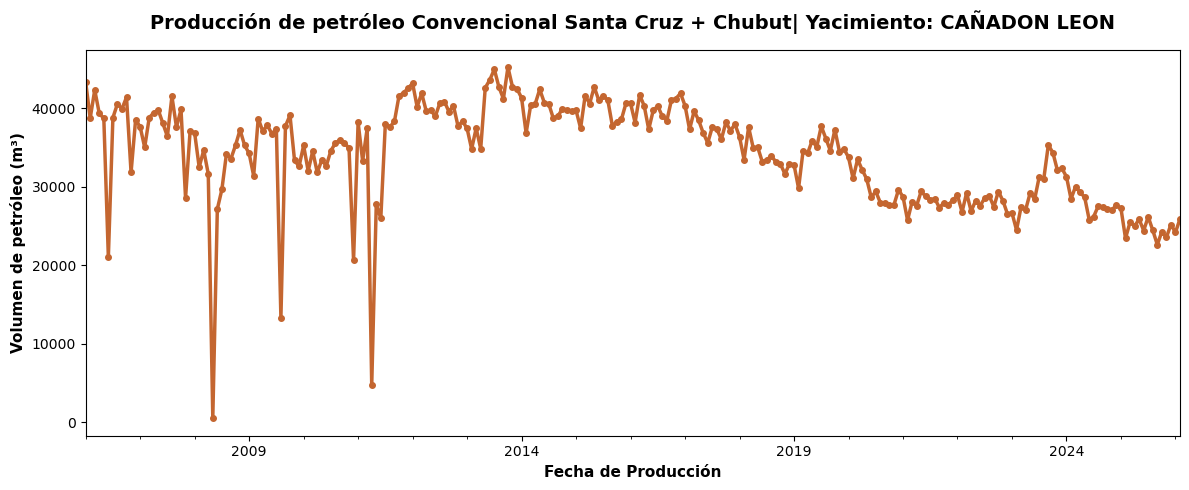

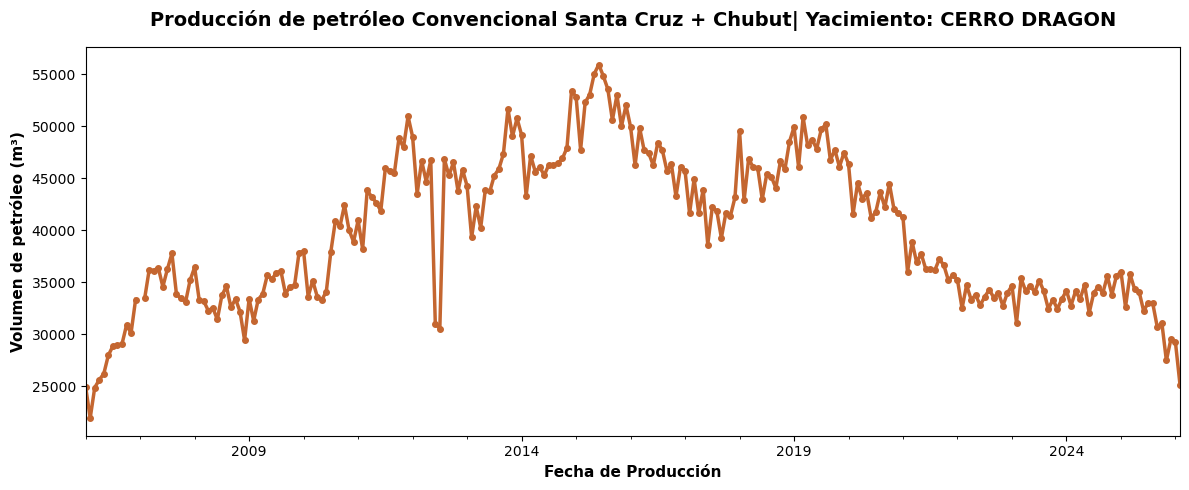

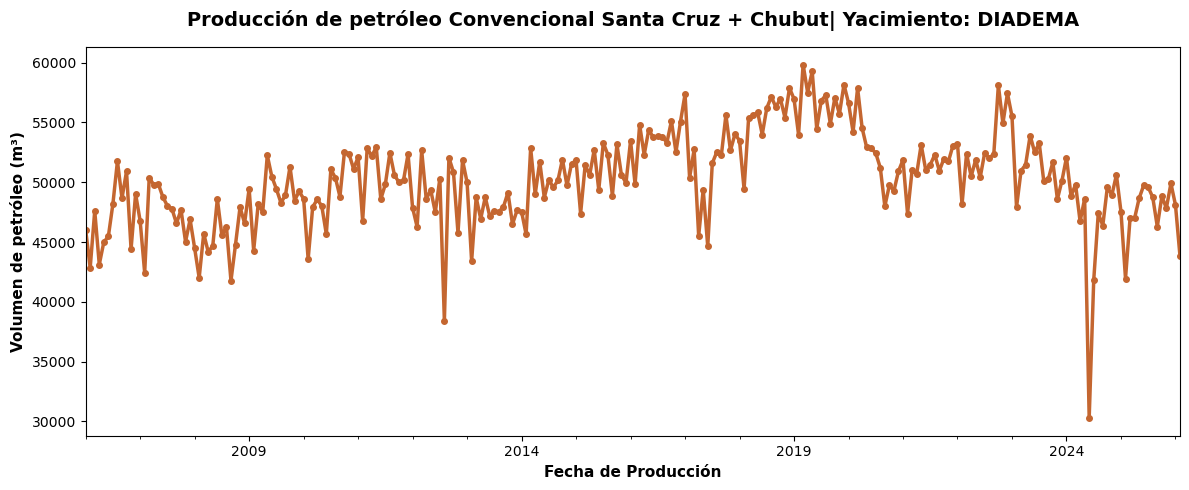

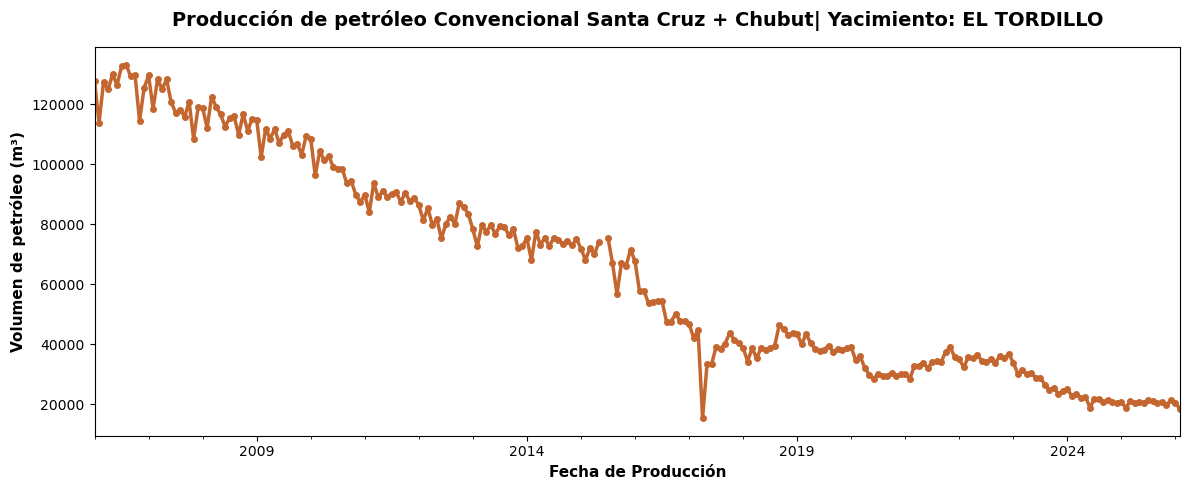

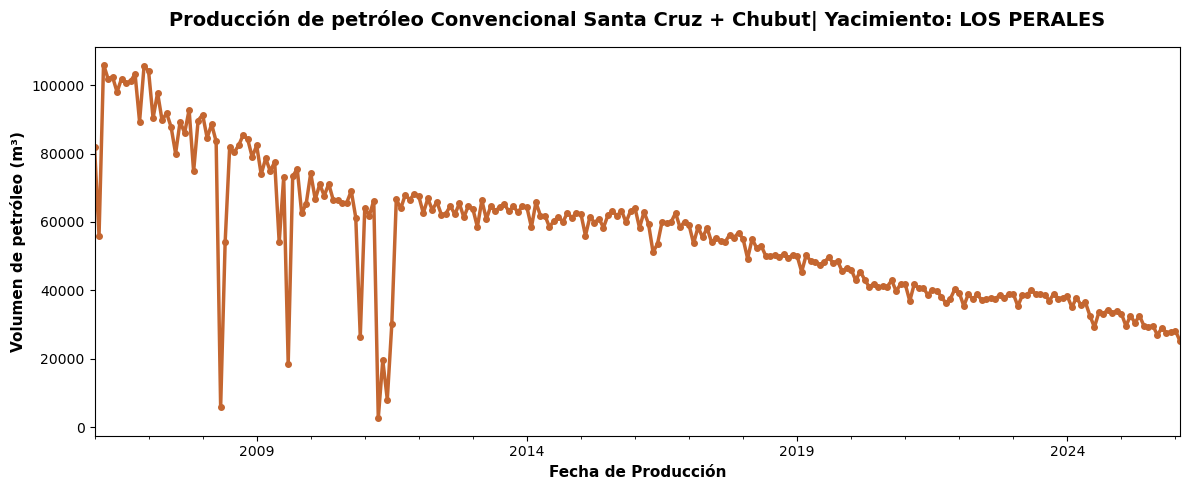

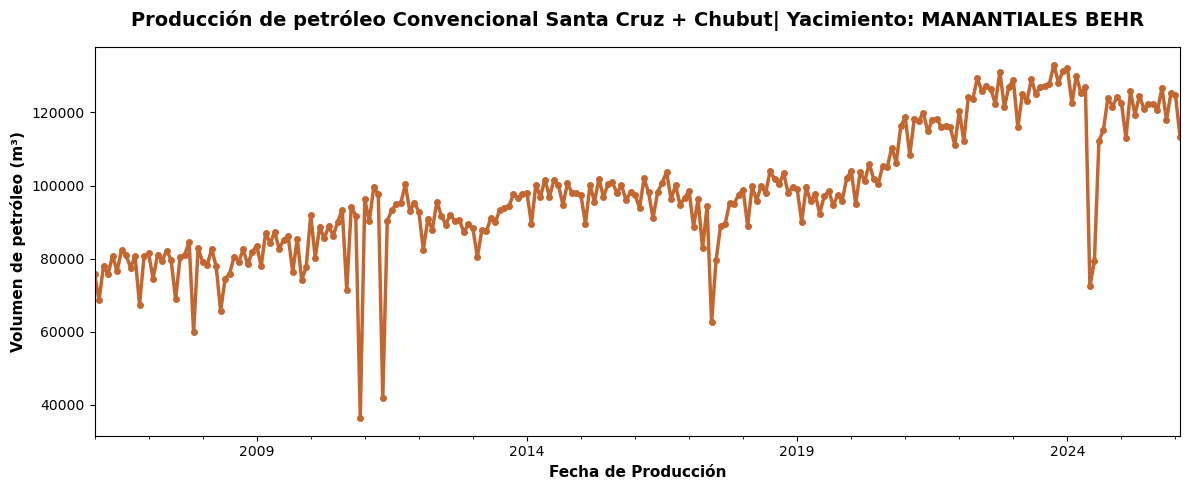

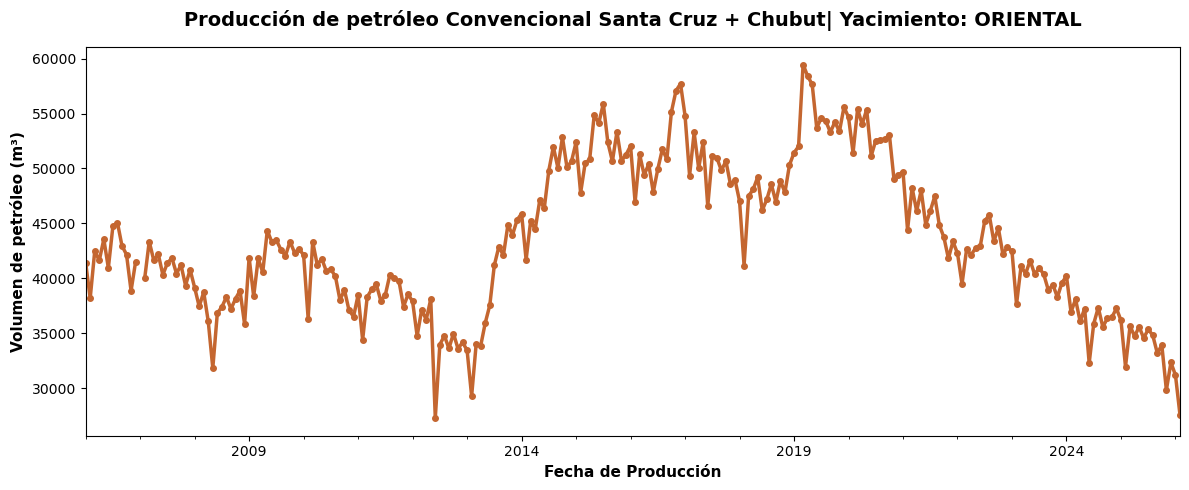

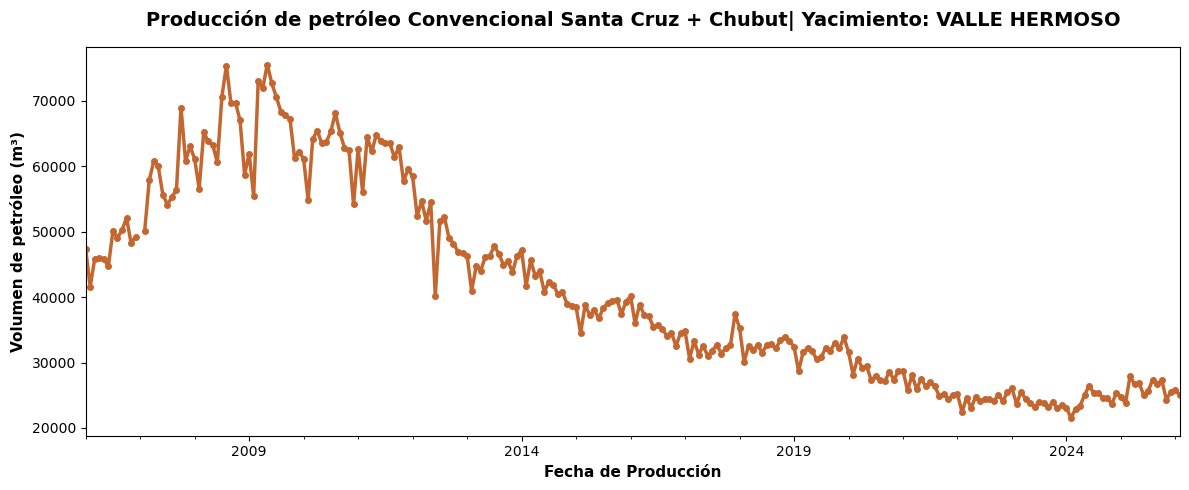

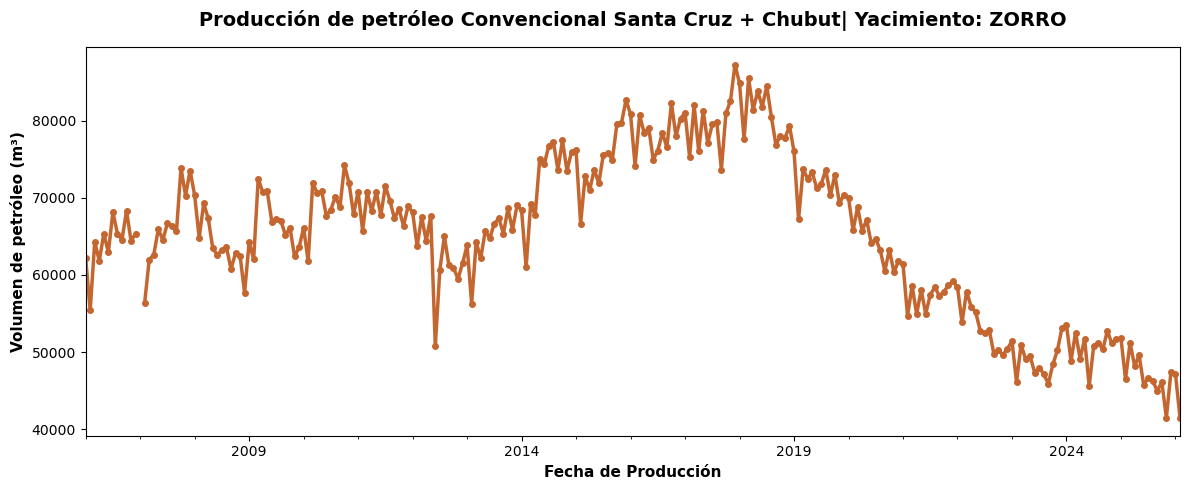

In [14]:
ranking_produccion = dataframe_petroleo_s_Neuquen.groupby("areayacimiento")["prod_pet"].sum()

top_10_nombres = ranking_produccion.nlargest(10).index #ordena los 10 yacimientos que mas produccion tienen y agarra los indices

df_top10 = dataframe_petroleo_s_Neuquen[dataframe_petroleo_s_Neuquen["areayacimiento"].isin(top_10_nombres)] #.isin agarra las filas que tengan el contenido del parentesis

datos_grafico = df_top10.pivot_table(index="fecha_produccion", columns="areayacimiento", values="prod_pet", aggfunc="sum")

for yacimiento in datos_grafico.columns:
    # 2. TUNEAR LA LÍNEA: Guardamos el gráfico en una variable 'ax' para modificarlo
    ax = datos_grafico[yacimiento].plot(
        figsize=(12, 5), 
        color="#c46630",       # Podés usar códigos Hexadecimales para colores modernos
        linewidth=2.5,         # Hacemos la línea un poco más gruesa (por defecto es muy finita)
        marker='o',            # Le ponemos un puntito marcando cada dato real
        markersize=4           # Tamaño de ese puntito
    )
    
    # 3. TUNEAR LOS TEXTOS: Títulos y etiquetas de los ejes
    # pad=15 separa un poquito el título del gráfico para que respire
    plt.title(f"Producción de petróleo Convencional Santa Cruz + Chubut| Yacimiento: {yacimiento}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Fecha de Producción", fontsize=11, fontweight='bold')
    plt.ylabel("Volumen de petróleo (m³)", fontsize=11, fontweight='bold')
    
    # 4. EMPROLIJAR: Esto evita que los textos se corten en los bordes de la imagen
    plt.tight_layout()
    
    # Mostramos el gráfico terminado
    plt.show()

Para Neuquén

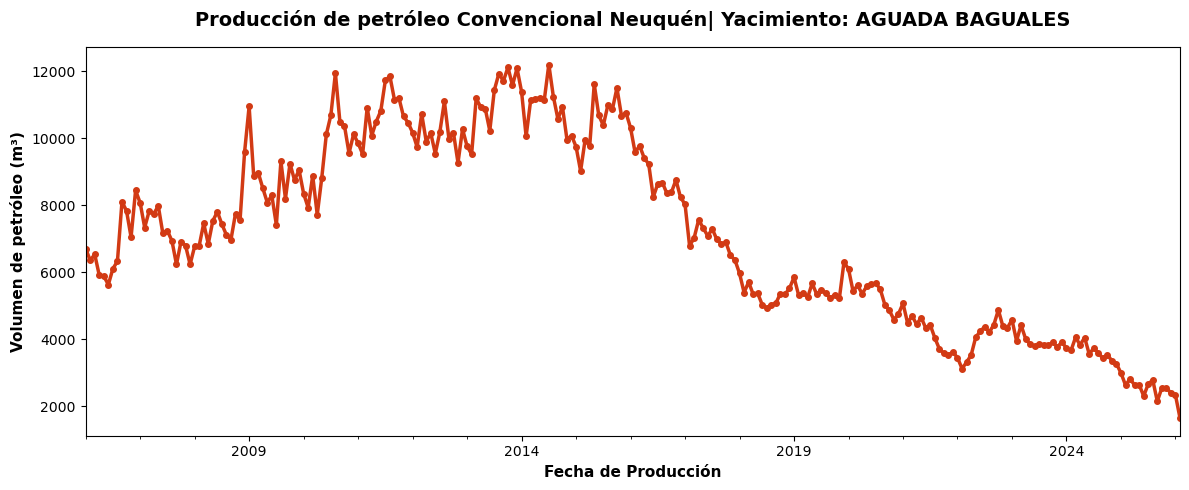

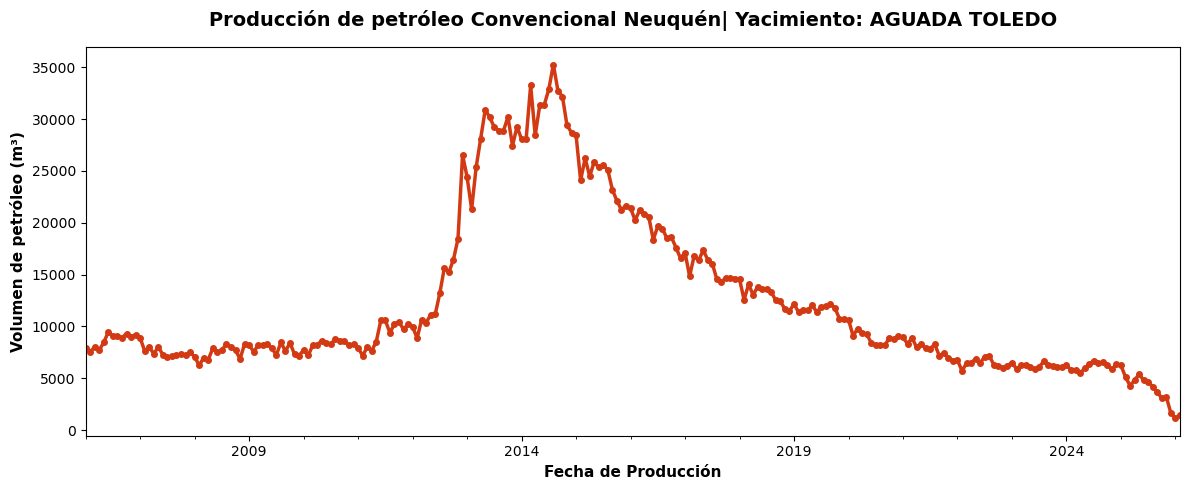

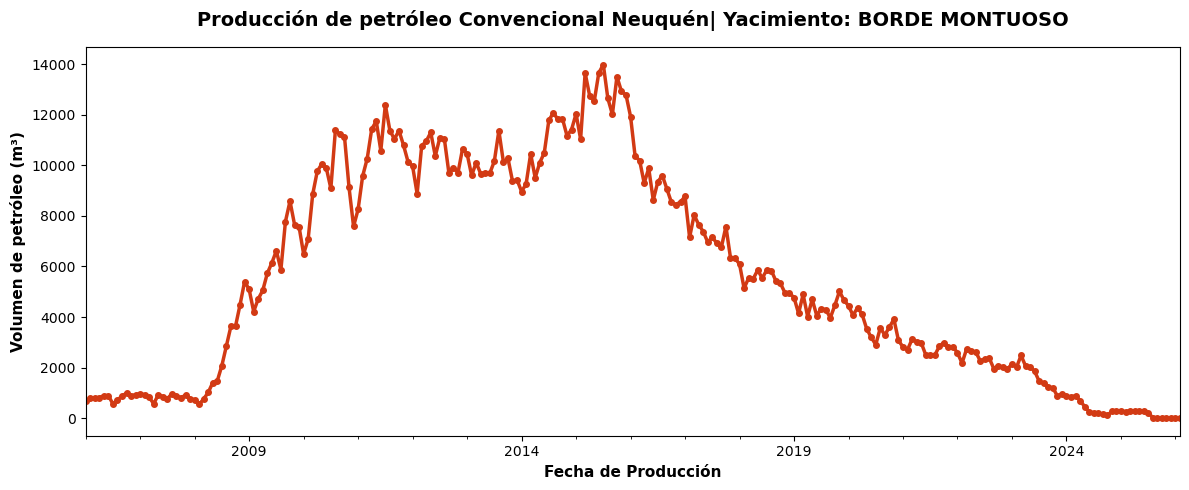

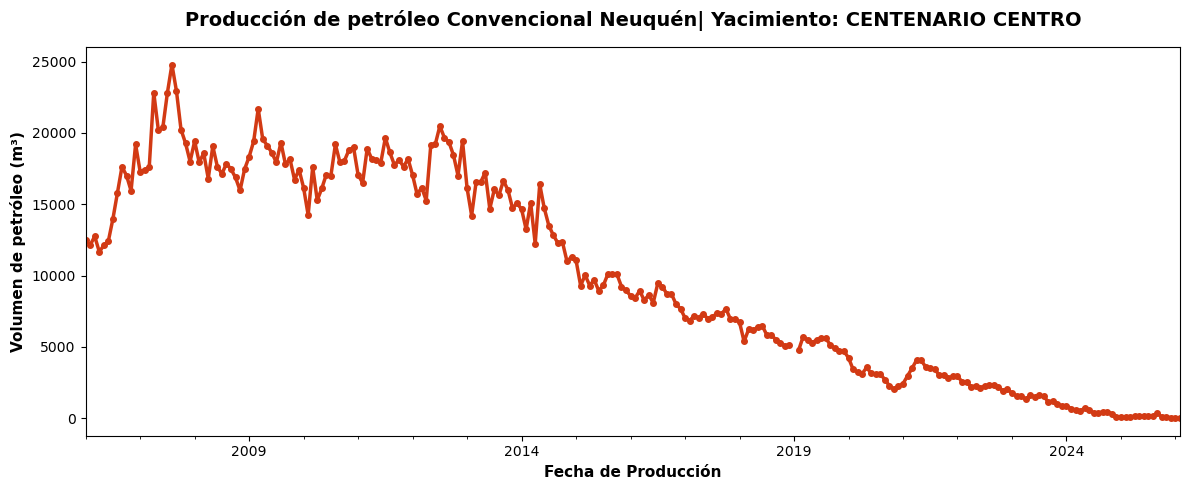

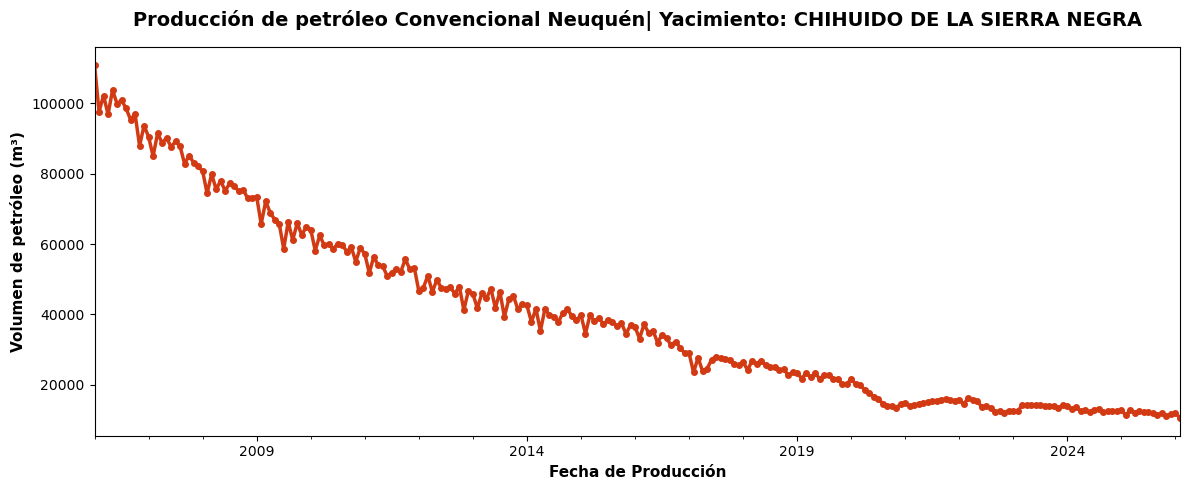

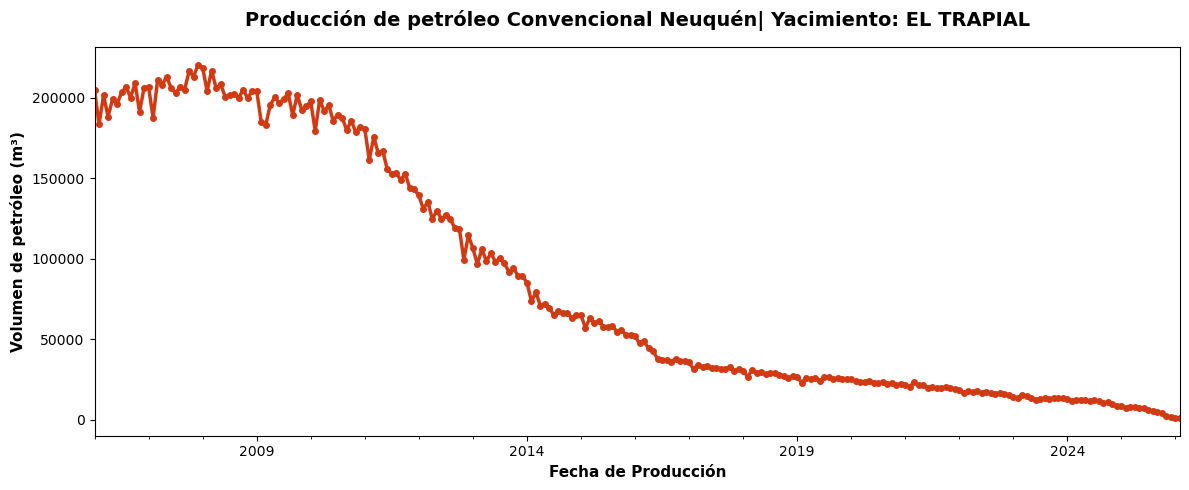

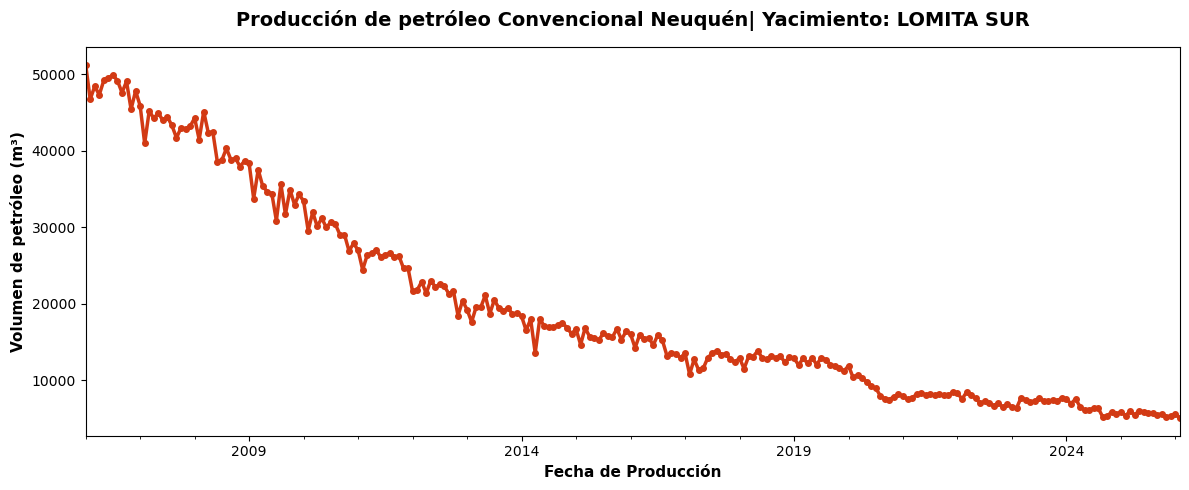

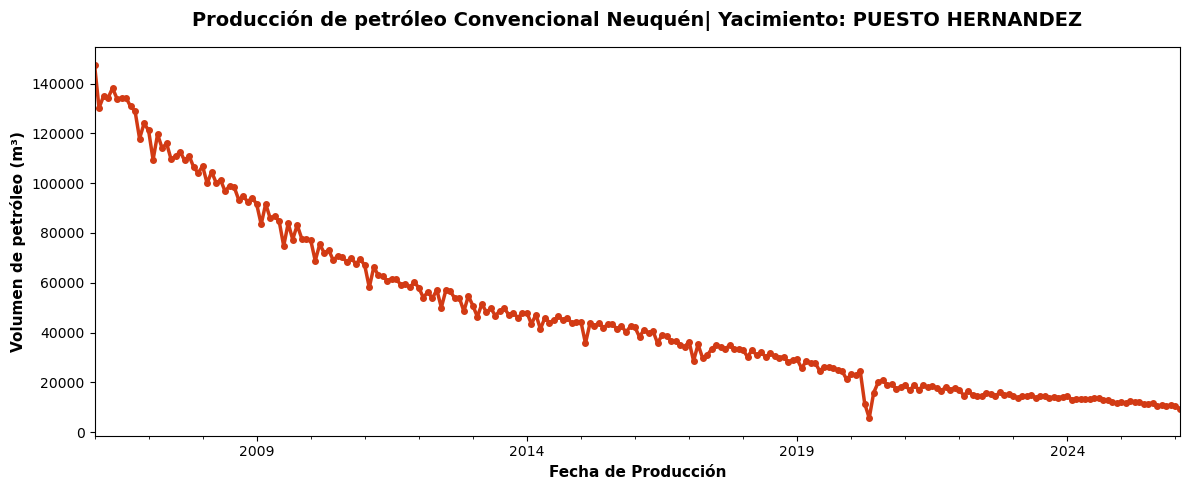

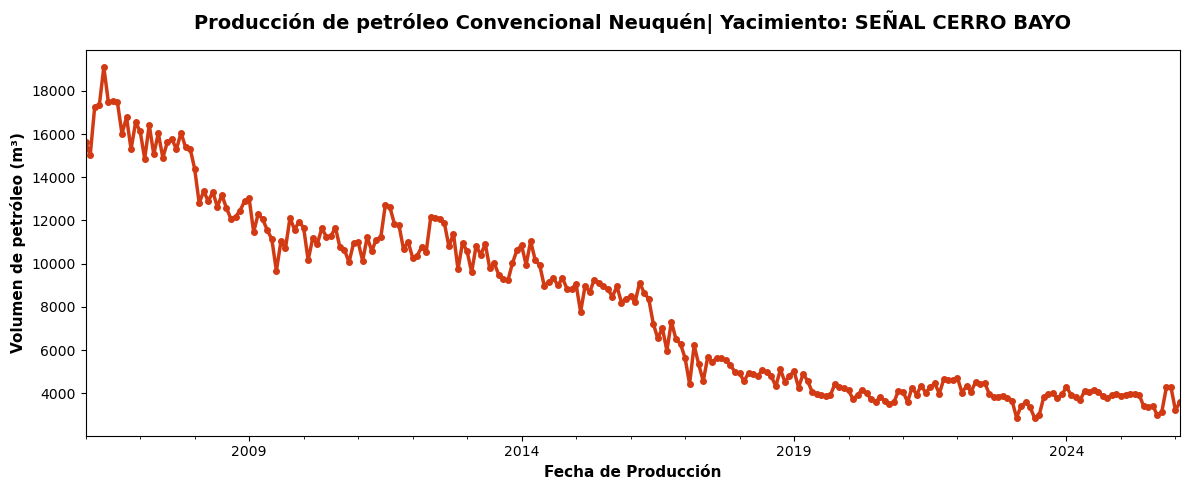

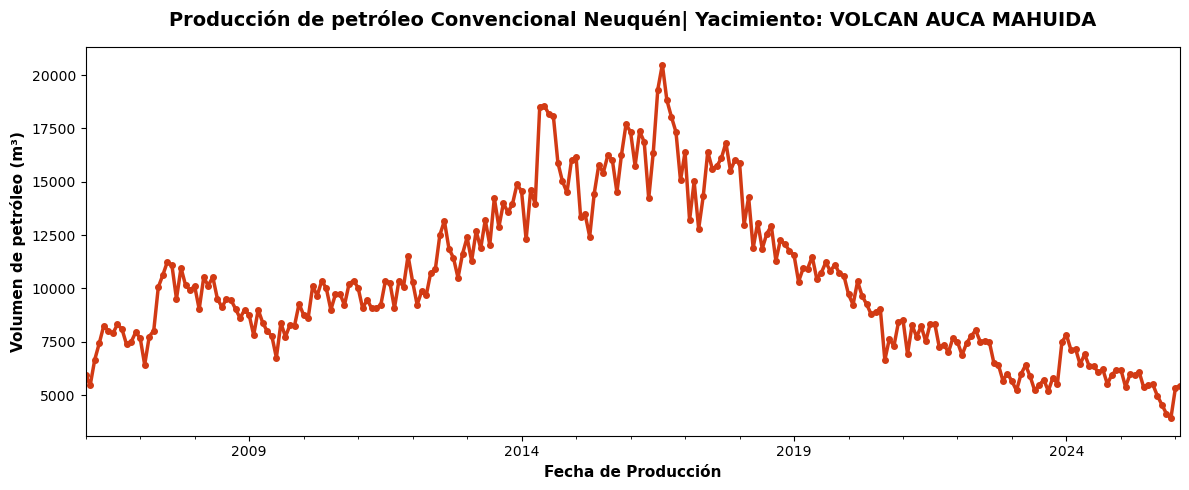

In [16]:
ranking_produccion = dataframe_petroleo_c_Neuquen.groupby("areayacimiento")["prod_pet"].sum()

top_10_nombres = ranking_produccion.nlargest(10).index #ordena los 10 yacimientos que mas produccion tienen y agarra los indices

df_top10 = dataframe_petroleo_c_Neuquen[dataframe_petroleo_c_Neuquen["areayacimiento"].isin(top_10_nombres)] #.isin agarra las filas que tengan el contenido del parentesis

datos_grafico = df_top10.pivot_table(index="fecha_produccion", columns="areayacimiento", values="prod_pet", aggfunc="sum")

for yacimiento in datos_grafico.columns:
    # 2. TUNEAR LA LÍNEA: Guardamos el gráfico en una variable 'ax' para modificarlo
    ax = datos_grafico[yacimiento].plot(
        figsize=(12, 5), 
        color="#d23a14",       # Podés usar códigos Hexadecimales para colores modernos
        linewidth=2.5,         # Hacemos la línea un poco más gruesa (por defecto es muy finita)
        marker='o',            # Le ponemos un puntito marcando cada dato real
        markersize=4           # Tamaño de ese puntito
    )
    
    # 3. TUNEAR LOS TEXTOS: Títulos y etiquetas de los ejes
    # pad=15 separa un poquito el título del gráfico para que respire
    plt.title(f"Producción de petróleo Convencional Neuquén| Yacimiento: {yacimiento}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Fecha de Producción", fontsize=11, fontweight='bold')
    plt.ylabel("Volumen de petróleo (m³)", fontsize=11, fontweight='bold')
    
    # 4. EMPROLIJAR: Esto evita que los textos se corten en los bordes de la imagen
    plt.tight_layout()
    
    # Mostramos el gráfico terminado
    plt.show()

## Liberador de memoria

In [17]:
del dataset #se borra el dataset original para ahorrar recursos
gc.collect()

12659

In [25]:
del dataframe_gas 
gc.collect()

55566

In [26]:
del dataframe_petroleo_c_Neuquen 
gc.collect()

0

In [27]:
del dataframe_petroleo_s_Neuquen 
gc.collect()

0

## Debug 

In [ ]:
dataframe_petroleo_c_Neuquen[""]